<a href="https://colab.research.google.com/github/SayanB58/HAAI__Cohort2_LLM_Tokenizers_Embeddings/blob/main/HAAI%2B%2B_cohort2_Hands_on_ModelQuantization_QLoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

By : Rajdeep Ghosh, Research Scholar, CSE-IITKGP

Reach out at [Linkedin](https://www.linkedin.com/in/ghoshrajdeep2000/) / Email: ghoshrajdeep2000@gmail.com

# Hands-on: Model Quantization, QLoRA & Evaluation


Modern LLMs are enormous. A 7-billion-parameter model in full precision needs ~28 GB **just to hold
the weights** — before you add activations, gradients, or an optimizer. Yet the GPU most people actually have (a laptop RTX, a free-Colab T4) has 8–16 GB.

**Quantization** is the bridge: it shrinks the numbers so the model fits, and **QLoRA** lets us *fine-tune* that shrunk model on a single GPU.

Today we go end-to-end, writing and running every piece.

**Learning outcomes.** By the end you will be able to:
1. Explain, with numbers, *why* quantization is needed and *how* linear/NF4 quantization works.
2. Load **LLaMA-2-7B in 4-bit (NF4)** on one consumer GPU and generate text.
3. Fine-tune it with **QLoRA** — training <1% of the parameters — on a real financial-QA dataset.
4. Evaluate **before vs after** with perplexity, ROUGE, loss curves, and side-by-side reading.
5. Save/deploy the result, and choose between quantization methods (bitsandbytes / GPTQ / AWQ / GGUF).



**Set your runtime now:** `Runtime → Change runtime type → T4 GPU → Save`.

## Part 0 — Environment & GPU setup

Three things before we touch a model:
1. Confirm a GPU is attached (and see how much VRAM it has).
2. Install a mutually-compatible library stack.
3. Detect the right compute precision **for this specific GPU** .

In [1]:
# Confirm the GPU. If this shows an error or 'command not found', you are on CPU:
# Runtime -> Change runtime type -> T4 GPU -> Save, then re-run.
# In the output, watch the 'Memory-Usage' column — that's your VRAM budget for the whole notebook.
!nvidia-smi

Sat Jul 25 05:50:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install the quantization + fine-tuning stack.
#   transformers  -> model loading, generation, the Trainer loop
#   datasets      -> stream real-world datasets from the Hugging Face Hub
#   accelerate    -> automatic device placement (device_map="auto")
#   peft          -> LoRA / QLoRA adapters
#   bitsandbytes  -> the actual 4-bit (NF4) quantization + 8-bit optimizer kernels
#   sentencepiece -> required by the LLaMA-2 tokenizer
#   rouge_score   -> ROUGE metrics used in the evaluation module
# (matplotlib/numpy are already in Colab; we just import them.)
!pip install -q -U transformers datasets accelerate peft bitsandbytes sentencepiece protobuf rouge_score

# If a LATER cell throws a bitsandbytes / CUDA error, the fix is almost always:
#   Runtime -> Restart session, then run from this cell down (do NOT re-run pip again).

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


In [3]:
# Core imports, reproducibility, and hardware-aware precision.
import os, time, gc, math, struct, warnings
from collections import Counter
import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")            # keep workshop output readable
torch.manual_seed(42); np.random.seed(42)    # reproducible runs

assert torch.cuda.is_available(), "No GPU! Set Runtime -> T4 GPU and restart."

# WHY precision detection matters:
#   BF16 (bfloat16) has FP32's exponent range but fewer mantissa bits -> stable for training.
#   BUT only NEWER GPUs (A100, L4) have BF16 hardware. The T4 (Turing) does NOT.
#   On a T4 we must fall back to FP16. We decide ONCE here and reuse everywhere.
USE_BF16      = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16

props = torch.cuda.get_device_properties(0)
print("GPU            :", props.name)
print("Total VRAM     : {:.1f} GB".format(props.total_memory / 1e9))
print("BF16 in HW?    :", USE_BF16, "(T4 = False -> we use FP16)")
print("Compute dtype  :", COMPUTE_DTYPE)

GPU            : Tesla T4
Total VRAM     : 15.6 GB
BF16 in HW?    : True (T4 = False -> we use FP16)
Compute dtype  : torch.bfloat16


In [4]:
# A reusable VRAM reporter. We'll call it after loading and around training so you can
# literally watch memory move — the whole reason quantization exists.
def gpu_report(tag=""):
    free, total = torch.cuda.mem_get_info()          # bytes free / total on the device
    used = (total - free) / 1e9
    alloc = torch.cuda.memory_allocated() / 1e9      # tensors PyTorch is actively holding
    resv  = torch.cuda.memory_reserved()  / 1e9      # memory PyTorch reserved from the driver
    print(f"[{tag:<22}] used {used:5.2f} GB / {total/1e9:.1f} GB  |  "
          f"allocated {alloc:5.2f} GB  |  reserved {resv:5.2f} GB")

gpu_report("startup (empty GPU)")

[startup (empty GPU)   ] used  0.11 GB / 15.6 GB  |  allocated  0.00 GB  |  reserved  0.00 GB


## Part 1 — How quantization actually works

Quantization is *controlled rounding + rescaling*: we represent many real-valued weights using a
small, fixed set of levels, store the levels plus a scale, and reconstruct approximate values on the
fly during computation. It works for two reasons:

- **Noise tolerance.** Deep nets are already trained with tons of noise (dropout, SGD stochasticity,
  mixed precision). Small weight perturbations rarely flip the final decision.
- **Averaging.** Each output depends on many weights interacting, so tiny per-weight errors tend to
  cancel out rather than accumulate.





### The core deployment problem
- Large Language Models contain billions of parameters (weights).Each parameter is usually stored as a 32-bit floating point number (FP32). So even loading the model becomes difficult.
- LLMs are **memory heavy**: most consumer GPUs have **8–24 GB VRAM**.
Example:
7B parameters × 4 bytes ≈ 28 GB memory. Just storing weights already exceeds many GPUs.
- Even inference for multi-billion parameter models can exceed GPU memory. During generation--- intermediate activations must be stored, attention key/value cache grows with sequence length. So memory ≠ just model size.
- Training/fine-tuning full weights is even more expensive. (Gradients, Optimizer states (Adam keeps 2 extra copies!), Forward activations)

### Two scenarios
1. **Inference deployment**: serve models on limited hardware → reduce memory footprint + sometimes faster inference. Quantization helps by:
- reducing weight precision (FP32 → INT8 / INT4)
- shrinking memory usage
- improving cache efficiency
- sometimes speeding up computation

2. **Fine-tuning**: adapt models without full retraining → QLoRA keeps base weights quantized, trains small adapters.

### Key idea

Intuition: Think of image compression:

--- RAW image → huge size

--- JPEG → much smaller

--- looks almost identical

Quantization does the same for neural networks.


Neural nets often contain **redundant numeric precision**. Reducing precision can preserve behavior while saving memory.


### 1.1 — Number formats: where the bits go

A floating-point number splits its bits into **sign · exponent · mantissa**:

| Format | Bits | Sign | Exponent | Mantissa | Character |
|---|---|---|---|---|---|
| FP32 | 32 | 1 | 8 | 23 | full precision (baseline) |
| FP16 | 16 | 1 | 5 | 10 | good precision, **narrow range** (can overflow in training) |
| BF16 | 16 | 1 | 8 | 7 | FP32's range, **coarser precision** — stable gradients |
| INT8 | 8 | — | — | — | 256 integer levels + a scale |
| INT4 | 4 | — | — | — | 16 integer levels + a scale |

- **Exponent bits → dynamic range** (how big/small a number can be).
- **Mantissa bits → precision** (how finely we distinguish nearby numbers).

BF16 keeps FP32's 8 exponent bits (same range → no overflow), sacrificing mantissa precision — which
is exactly the right trade for training. Let's *see* the precision loss on a single number.

In [5]:
# See rounding error when we squeeze 0.1 into fewer bits.
# 0.1 is not exactly representable in binary, so every format rounds it differently.
def f32_bitstring(x):
    # pack the float as 4 big-endian bytes, read as an int, show 32 bits
    return format(int.from_bytes(struct.pack('>f', x), 'big'), '032b')

x = 0.1
bits = f32_bitstring(x)
print("FP32 bit layout of 0.1:")
print(f"  sign={bits[0]}  exponent={bits[1:9]}  mantissa={bits[9:]}")
print()

print(f"{'dtype':<12}{'stored value':<24}{'abs error vs 0.1':<18}")
print("-" * 54)
for dt, name in [(torch.float32,'float32'), (torch.float16,'float16'), (torch.bfloat16,'bfloat16')]:
    v = torch.tensor(0.1, dtype=torch.float32).to(dt).item()  # round-trip through the low-precision dtype
    print(f"{name:<12}{repr(v):<24}{abs(v - 0.1):<18.3e}")

# Notice bfloat16 has the LARGEST rounding error of the three (only 7 mantissa bits) —
# yet it's preferred for training because its wide exponent range prevents overflow/underflow.

FP32 bit layout of 0.1:
  sign=0  exponent=01111011  mantissa=10011001100110011001101

dtype       stored value            abs error vs 0.1  
------------------------------------------------------
float32     0.10000000149011612     1.490e-09         
float16     0.0999755859375         2.441e-05         
bfloat16    0.10009765625           9.766e-05         


#### Half Precision (FP16)
- **Structure**: 1 sign + 5 exponent + 10 mantissa bits (fairly good precision)
- **Memory reduction**: Exactly 50%, widely supported by modern hardware
- **Trade-offs**: Minimal accuracy loss, but reduced dynamic range can cause training instability
- **Best use**: Inference and stable training scenarios

#### Brain Float (BF16)  
- **Structure**: 1 sign + 8 exponent + 7 mantissa bits (less precise per value)
- **Key advantage**: Same exponent range as FP32 (better numerical stability)
- **Google's innovation**: Designed specifically for machine learning workloads
- **Trade-off**: Less mantissa precision than FP16, but more robust gradients

#### Integer Quantization
- **INT8**: 256 discrete levels, 75% memory reduction from FP32
  - Requires calibration dataset to determine optimal mapping
  - Well-supported by inference engines (TensorRT, ONNX Runtime)
- **INT4**: 16 discrete levels, 87.5% memory reduction
  - Aggressive quantization, needs sophisticated techniques to maintain quality
  - Enables deployment of 7B models on consumer hardware


#### The unavoidable triangle
You are always trading among:
1. Memory footprint
2. Speed (sometimes)
3. Accuracy / generation quality

In short: FP16/BF16 are “safe + easy,” INT8 is often “fast + safe-ish,” INT4 is “maximum compression with careful engineering.”


### 1.2 — Quantization

Quantization maps real-valued weights/activations to a smaller set of representable values while preserving model functionality

or

Quantization is just a controlled rounding + re-scaling scheme that lets us represent many real numbers using a small, fixed set (like int8 has only 256 values), while keeping the network’s computations “close enough.






#### Linear quantization: scale (S) and zero-point (Z)

The workhorse recipe maps a real value `r` to an integer level and back:

- **Quantize:**  `Q(r) = round(r / S) + Z`
- **Dequantize:** `r̃ = S · (Q − Z)`

where **S** (scale) is the width of one bucket and **Z** (zero-point) is which integer level
represents 0. Two flavours:

- **Symmetric** (`Z = 0`): range centered on 0. Simpler, cheaper hardware. Good for **weights**
  (roughly zero-mean in transformers).
- **Asymmetric** (`Z ≠ 0`): shifts the range to cover skewed data. Good for **activations**
  (post-ReLU/GeLU values are often mostly positive with long tails).

Let's quantize the same data both ways and compare the reconstruction error.

In [6]:
# Skewed, mostly-positive data (like post-activation values).
data = np.abs(np.random.randn(20000)).astype(np.float32) * 3.0   # all >= 0, long right tail

def quant_symmetric(x, n_bits=8):
    qmax = 2**(n_bits-1) - 1                 # e.g. 127 for int8; Z is fixed at 0
    S = np.abs(x).max() / qmax               # scale from the max magnitude
    q = np.clip(np.round(x / S), -qmax-1, qmax)
    return q * S, S                          # dequantized values, scale

def quant_asymmetric(x, n_bits=8):
    qmin, qmax = 0, 2**n_bits - 1            # e.g. [0, 255] for uint8
    lo, hi = x.min(), x.max()
    S = (hi - lo) / (qmax - qmin)            # scale spans the ACTUAL data range
    Z = qmin - np.round(lo / S)              # zero-point shifts range to cover [lo, hi]
    q = np.clip(np.round(x / S) + Z, qmin, qmax)
    return (q - Z) * S, S, Z                 # dequantized values, scale, zero-point

deq_sym, S_sym       = quant_symmetric(data, 8)
deq_asym, S_asym, Z  = quant_asymmetric(data, 8)

mse_sym  = np.mean((data - deq_sym)**2)
mse_asym = np.mean((data - deq_asym)**2)
print(f"Symmetric  8-bit : scale={S_sym:.5f}            MSE={mse_sym:.6e}")
print(f"Asymmetric 8-bit : scale={S_asym:.5f}  Z={Z:.0f}   MSE={mse_asym:.6e}")
print(f"\nAsymmetric is ~{mse_sym/mse_asym:.1f}x more accurate here because the data is skewed:")
print("symmetric 'wastes' half its levels on negative values that barely occur.")

Symmetric  8-bit : scale=0.10581            MSE=9.286797e-04
Asymmetric 8-bit : scale=0.05269  Z=0   MSE=2.316195e-04

Asymmetric is ~4.0x more accurate here because the data is skewed:
symmetric 'wastes' half its levels on negative values that barely occur.


### 1.3 — Per-tensor vs per-channel, and the outlier problem

Every quantization scheme needs a **scale `S`** that maps real values onto the integer levels. But a
scale never applies to *one* number — it's shared across a whole **group** of weights. The key design
question is: *how big is that group?* This is called **granularity**, and it turns out to matter a lot.



- **Per-tensor:** one single `S` for the entire weight matrix. Cheapest to store (one number), but
  every weight is at the mercy of that one scale.
- **Per-channel:** one `S` **per row (or column)**. Slightly more metadata, far more robust.

**Why the group size matters — the outlier problem.** The scale is set by the *largest* magnitude in
the group: with INT8 we spread 256 levels evenly from `−max` to `+max`, so the bucket width is
`S = max / 127`. Now suppose 99% of the weights sit around ±1, but a single **outlier** is around ±25.
With one per-tensor scale, `S` is forced ~25× wider to reach that outlier — and all the *normal* ±1
values now fall into just a couple of buckets near zero. We've spent almost all our precision
describing one big number and crushed everyone else into near-nothing. The outlier **hijacks the scale**
for the whole tensor.

**The fix.** Give each row its own scale. Then the outlier only blows up the scale of *its own* row;
every other row keeps a tight scale and full resolution. The error stays contained instead of
spreading across the matrix.

**Why this is central to LLMs specifically.** Transformer weights and activations are famous for having
a handful of persistent **outlier channels** — a few dimensions that are consistently much larger than
the rest. That's exactly the pathological case above, at scale. It's why modern LLM quantizers never
use a single global scale: `LLM.int8()` isolates outlier dimensions, GPTQ/AWQ quantize per-channel, and
the **NF4** format we use in QLoRA quantizes **per-block** (a small group of weights shares a scale) —
a practical middle ground between per-tensor and per-channel.

In the demo below we make the problem concrete: build a matrix whose **row 0 is 25× larger** than the
rest, quantize it both ways, and measure the reconstruction error **on the normal rows** — the values
we actually care about preserving.

In [8]:
# A weight matrix where ROW 0 has large outliers and the other rows are small/normal.
W = np.random.randn(4, 8).astype(np.float32)
W[0] *= 25.0                                  # outlier channel

# Per-TENSOR: one scale for the whole matrix (dominated by the outlier row).
S_t = np.abs(W).max() / 127
W_pt = np.round(W / S_t) * S_t

# Per-CHANNEL: one scale PER ROW (each row uses its own max).
S_c  = np.abs(W).max(axis=1, keepdims=True) / 127
W_pc = np.round(W / S_c) * S_c

# Compare error on the NORMAL rows (1..3), which is what we care about preserving.
err_pt = np.mean((W[1:] - W_pt[1:])**2)
err_pc = np.mean((W[1:] - W_pc[1:])**2)
print(f"Per-tensor  MSE on normal rows : {err_pt:.6e}")
print(f"Per-channel MSE on normal rows : {err_pc:.6e}")
print(f"\nPer-channel is ~{err_pt/err_pc:.0f}x better on the normal rows — the outlier row no longer")
print("hijacks everyone else's scale. This is why LLM quantizers quantize per-channel/per-block.")

Per-tensor  MSE on normal rows : 9.023865e-03
Per-channel MSE on normal rows : 2.622749e-05

Per-channel is ~344x better on the normal rows — the outlier row no longer
hijacks everyone else's scale. This is why LLM quantizers quantize per-channel/per-block.


### 1.4 — The precision cliff: error vs bit-width

Fewer bits = less memory, but error grows — and not linearly. Below ~4 bits, naive uniform
quantization error rises sharply. Let's sweep bit-widths and plot it.

We've seen *how* to place quantization levels (scale, zero-point, granularity). Now the obvious
question: **how few bits can we get away with?** Every bit we drop halves the number of available
levels — 8-bit gives 256 levels, 4-bit gives 16, 2-bit gives just 4 — so intuitively, fewer bits means
more rounding error. The important part is *how* that error grows.

**It's not a gentle slope — it's a cliff.** Because each bit removed **halves** the level count, the
spacing between levels roughly **doubles** with every bit you cut. Error scales with that spacing, so it
grows *geometrically*, not linearly. Going 8→7→6 bits barely moves the needle: you still have plenty of
levels to describe a bell-curve of weights, so quality is nearly untouched. But keep going and you fall
off an edge — around 3–2 bits there are so few buckets that whole ranges of distinct weights collapse
onto the same value, and the reconstruction error shoots up. Plotted on a log scale, this shows up as a
line that's flat-ish on the left and then rockets upward on the right.

**Why 4-bit is the interesting spot.** Notice *where* the cliff is. At 8, 6, even 5 bits, naive uniform
rounding is basically fine — you wouldn't need anything clever. It's right around **4 bits** that the
error becomes large enough to hurt a model, yet 4 bits is also where the memory savings get exciting
(~8× smaller than FP32). That tension is the whole reason 4-bit quantization is a research topic at all:
it sits at the edge of the cliff, close enough to the drop that *how* you quantize suddenly matters. A
naive uniform grid wastes precision here; a smarter, distribution-aware scheme can claw back much of the
lost accuracy at the *same* 4 bits — which is exactly what NF4 does in the next section.

In the demo below we quantize the same Gaussian "weights" at bit-widths from 8 down to 2, measure the
mean-squared reconstruction error at each, and plot it (log scale, fewer bits toward the right) so the
cliff is visible.

8-bit : MSE = 1.029805e-04
7-bit : MSE = 4.189670e-04
6-bit : MSE = 1.735805e-03
5-bit : MSE = 7.392676e-03
4-bit : MSE = 3.378424e-02
3-bit : MSE = 1.845701e-01
2-bit : MSE = 9.226714e-01


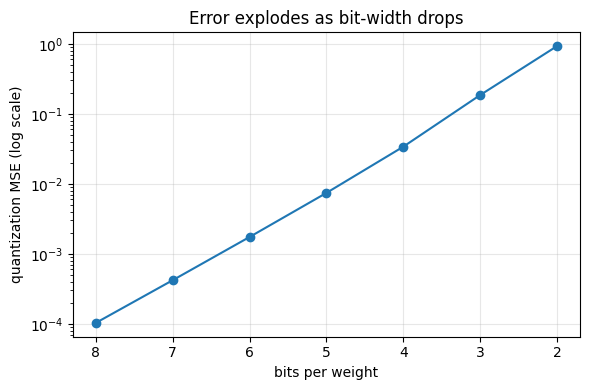


This is why 4-bit needs a SMARTER scheme than uniform rounding -> next: NF4.


In [7]:
# Standard normal 'weights'. Measure reconstruction MSE at each bit-width.
w = np.random.randn(50000).astype(np.float32)

def uniform_quant_mse(x, n_bits):
    qmax = 2**(n_bits-1) - 1                   # symmetric signed range
    S = np.abs(x).max() / qmax
    dq = np.round(x / S) * S
    return np.mean((x - dq)**2)

bit_widths = [8, 7, 6, 5, 4, 3, 2]
mses = [uniform_quant_mse(w, b) for b in bit_widths]
for b, e in zip(bit_widths, mses):
    print(f"{b}-bit : MSE = {e:.6e}")

plt.figure(figsize=(6,4))
plt.plot(bit_widths, mses, marker="o")
plt.gca().invert_xaxis()                        # fewer bits toward the right
plt.yscale("log")
plt.xlabel("bits per weight"); plt.ylabel("quantization MSE (log scale)")
plt.title("Error explodes as bit-width drops")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nThis is why 4-bit needs a SMARTER scheme than uniform rounding -> next: NF4.")

### 1.5 — NF4: distribution-aware 4-bit (what QLoRA uses)

Uniform INT4 spaces its 16 levels evenly. But neural-net weights are roughly **Gaussian** — most
mass sits near zero. **NF4 (NormalFloat4)** instead places its 16 levels at the *quantiles* of a
normal distribution, so it spends resolution where the data actually is. We'll approximate that idea
with quantile-based levels and show it beats uniform INT4 on Gaussian data.


Section 1.4 left us at the edge of the cliff: 4 bits is where naive rounding starts to hurt but the
memory savings are too good to give up. So the question becomes — *if we only get 16 levels, where
should we put them?* Uniform INT4 answers "space them evenly." That sounds fair, but it quietly assumes
every value is equally likely. Neural-net weights are not like that at all.

**The mismatch.** Trained weights are roughly **Gaussian** — a bell curve centered on zero. The vast
majority sit close to 0; large values are rare. Uniform quantization ignores this and hands out just as
many levels to the empty tails (where almost no weights live) as to the crowded middle (where almost all
of them do). It's like printing a map with the same detail for the ocean as for the city — most of the
resolution is wasted on regions nobody visits, while the dense, important region near zero gets too few
levels to separate similar weights.

**The fix: put levels where the data is.** **NF4 (NormalFloat4)** places its 16 levels at the
**quantiles** of a normal distribution instead of evenly. Quantiles are "equal-population" cut points —
each level is responsible for roughly the same *number* of weights. The practical effect is levels that
are **dense near zero** (fine resolution where the mass is) and **sparse in the tails** (a few coarse
levels are plenty for the rare big values). Same 16 levels, same 4 bits of storage — but spent far more
wisely, so the average rounding error drops.

**Two details worth knowing** (so the demo isn't mistaken for the real thing):
- Real NF4 is **information-theoretically derived** from the standard normal, not re-estimated from your
  data each time — it uses a fixed, precomputed set of levels, which is cheap and stable.
- Real NF4 is also **per-block**: it splits the weights into small blocks, normalizes each block by its
  own scale, then applies those normal-shaped levels — combining the granularity idea from 1.3 with the
  distribution-aware idea here. Our demo skips the per-block normalization and just approximates the
  level placement with empirical quantiles.

In the demo below we quantize the same Gaussian "weights" two ways at 4 bits — evenly-spaced (uniform
INT4) versus quantile-placed (the NF4 idea) — and compare the reconstruction error to see how much we
recover just by *moving the levels to where the data actually lives.*

In [9]:
# Gaussian 'weights'.
w = np.random.randn(50000).astype(np.float32)

# (a) Uniform INT4: 16 evenly spaced levels.
qmax = 7
S = np.abs(w).max() / qmax
dq_uniform = np.round(w / S) * S
mse_uniform = np.mean((w - dq_uniform)**2)

# (b) Quantile-based 16 levels (the NF4 idea: dense near 0, sparse in the tails).
levels = np.quantile(w, np.linspace(0, 1, 16)).astype(np.float32)
idx = np.abs(w[:, None] - levels[None, :]).argmin(axis=1)   # snap each value to nearest level
dq_quant = levels[idx]
mse_quant = np.mean((w - dq_quant)**2)

print(f"Uniform INT4   (even levels)     : MSE = {mse_uniform:.6e}")
print(f"Quantile 'NF4' (level near mass) : MSE = {mse_quant:.6e}")
print(f"\nDistribution-aware placement is ~{mse_uniform/mse_quant:.1f}x more accurate at the SAME 4 bits.")
print("Real NF4 also normalizes per-block; this demo just shows the core intuition.")

Uniform INT4   (even levels)     : MSE = 3.386155e-02
Quantile 'NF4' (level near mass) : MSE = 4.459284e-02

Distribution-aware placement is ~0.8x more accurate at the SAME 4 bits.
Real NF4 also normalizes per-block; this demo just shows the core intuition.


### 1.6 — Where memory goes: training vs inference (and why QLoRA)

Storing weights is only part of the story. During **training** you also pay for:

| Component | Cost (FP32) | Why |
|---|---|---|
| Weights | 4·P | the parameters themselves |
| Gradients | 4·P | one per weight, from backprop |
| Adam states | 8·P | momentum + variance, two extra copies |
| Activations | varies | cached for the backward pass |

So full fine-tuning of a 7B model needs **~16·P bytes = ~112 GB** before activations — impossible on
one consumer GPU. **Inference** drops gradients + optimizer, leaving ~4·P (28 GB FP32, ~3.5 GB in 4-bit).

**QLoRA's trick:** freeze the base in 4-bit (tiny) and train only small adapters — so *fine-tuning*
memory collapses toward *inference* memory. Let's compute the exact numbers.

In [10]:
P = 7e9   # LLaMA-2-7B parameter count

def gb(n_bytes): return n_bytes / 1e9

print("=== FULL FINE-TUNING in FP32 (the naive approach) ===")
w, g, o = gb(4*P), gb(4*P), gb(8*P)
print(f"  weights (4P)        : {w:6.1f} GB")
print(f"  gradients (4P)      : {g:6.1f} GB")
print(f"  Adam states (8P)    : {o:6.1f} GB")
print(f"  TOTAL (no activ.)   : {w+g+o:6.1f} GB   <- needs a multi-GPU server\n")

print("=== INFERENCE ONLY ===")
print(f"  FP16 weights (2P)   : {gb(2*P):6.1f} GB")
print(f"  4-bit weights (0.5P): {gb(0.5*P):6.1f} GB   <- fits a 15 GB GPU easily\n")

print("=== QLoRA FINE-TUNING (what we do today) ===")
base = gb(0.5*P)                     # frozen 4-bit base
adapter = gb(0.5*0.005*P*16)         # rough: adapters ~0.5% params, with grad+opt overhead
print(f"  frozen 4-bit base   : {base:6.2f} GB")
print(f"  adapters + grads/opt: ~{adapter:5.2f} GB (tiny)")
print(f"  approx trainable mem: ~{base+adapter:5.2f} GB   <- one 15 GB GPU is plenty")
print("\nQLoRA turns a 112 GB job into a single-GPU job. That's the headline.")

=== FULL FINE-TUNING in FP32 (the naive approach) ===
  weights (4P)        :   28.0 GB
  gradients (4P)      :   28.0 GB
  Adam states (8P)    :   56.0 GB
  TOTAL (no activ.)   :  112.0 GB   <- needs a multi-GPU server

=== INFERENCE ONLY ===
  FP16 weights (2P)   :   14.0 GB
  4-bit weights (0.5P):    3.5 GB   <- fits a 15 GB GPU easily

=== QLoRA FINE-TUNING (what we do today) ===
  frozen 4-bit base   :   3.50 GB
  adapters + grads/opt: ~ 0.28 GB (tiny)
  approx trainable mem: ~ 3.78 GB   <- one 15 GB GPU is plenty

QLoRA turns a 112 GB job into a single-GPU job. That's the headline.


## Part 2 — Module 1: Run a quantized LLaMA-2 locally (4-bit NF4)

Time to load a real 7B model in 4-bit and generate text on one GPU.

**Model choice.** We use `NousResearch/Llama-2-7b-hf`, an **ungated public mirror of Meta's
LLaMA-2-7B** with identical weights — so the whole class runs with zero access-request friction. If
you need Meta's official gated repo, see the commented block (you'll need a granted HF token).

In [11]:
# The model we load + fine-tune today. Ungated LLaMA-2-7B mirror -> no token needed.
model_name = "NousResearch/Llama-2-7b-hf"

# ----- OPTIONAL: Meta's official gated repo instead -----
# 1) Request access: https://huggingface.co/meta-llama/Llama-2-7b-hf
# 2) Colab left sidebar -> key icon (Secrets) -> add HF_TOKEN -> enable notebook access
# 3) Uncomment:
# from google.colab import userdata
# os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
# model_name = "meta-llama/Llama-2-7b-hf"
print("Using model:", model_name)

Using model: NousResearch/Llama-2-7b-hf


### 2.1 — `BitsAndBytesConfig`: the 4-bit recipe

This object tells Transformers *how* to quantize while loading. The four settings below are the
standard QLoRA recipe. Two knobs worth knowing:

- `bnb_4bit_quant_type`: `"nf4"` (distribution-aware, our default) vs `"fp4"` (plain 4-bit float).
- `bnb_4bit_use_double_quant`: also quantize the scales themselves — saves ~0.4 bits/param.

In [12]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    # Store weights in 4-bit instead of 16/32-bit -> ~8x smaller than FP32.
    # (STORAGE is 4-bit; the matrix multiplies still run in higher precision.)
    load_in_4bit=True,

    # NF4 = NormalFloat4: places its 16 levels at the quantiles of a normal distribution
    # (the idea we demoed in 1.5) -> better accuracy than uniform INT4.
    bnb_4bit_quant_type="nf4",

    # Even though weights are stored in 4-bit, the actual math runs in this dtype.
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,

    # Double quantization: quantize the quantization CONSTANTS too. Extra memory win,
    # negligible accuracy cost. Standard for QLoRA.
    bnb_4bit_use_double_quant=True,
)
print("4-bit NF4 config ready:", bnb_config.quant_method if hasattr(bnb_config,'quant_method') else 'bnb-4bit')

4-bit NF4 config ready: QuantizationMethod.BITS_AND_BYTES


### 2.2 — Tokenizer and a look at tokenization

The tokenizer converts text ↔ integer token IDs. LLaMA uses a SentencePiece/BPE tokenizer. Let's
load it and *see* how a prompt becomes tokens — token count directly drives memory and speed.

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
# Causal LMs ship without a pad token; reuse EOS so batching/padding works.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Vocab size :", tokenizer.vocab_size)
print("Pad token  :", tokenizer.pad_token, "| EOS:", tokenizer.eos_token, "| BOS:", tokenizer.bos_token)

# Peek at how a real prompt is tokenized.
sample = "### Question:\nWhat is an ETF?\n\n### Response:\n"
enc = tokenizer(sample)
print(f"\nPrompt -> {len(enc['input_ids'])} tokens")
print("First IDs   :", enc["input_ids"][:16])
print("First tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"])[:16])
# The odd characters (like the underscore-looking glyph) mark word boundaries in SentencePiece.

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

Vocab size : 32000
Pad token  : <unk> | EOS: </s> | BOS: <s>

Prompt -> 18 tokens
First IDs   : [1, 835, 894, 29901, 13, 5618, 338, 385, 382, 8969, 29973, 13, 13, 2277, 29937, 13291]
First tokens: ['<s>', '▁###', '▁Question', ':', '<0x0A>', 'What', '▁is', '▁an', '▁E', 'TF', '?', '<0x0A>', '<0x0A>', '##', '#', '▁Response']


### 2.3 — Load the model in 4-bit and watch the memory

First load downloads ~13 GB of weights (a few minutes), then quantizes them to 4-bit on the GPU.
We print the real footprint and compare against what FP16 would have cost.

In [14]:
from transformers import AutoModelForCausalLM

print("Loading LLaMA-2-7B in 4-bit NF4... (first run downloads ~13 GB)")
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,   # apply the 4-bit recipe
    device_map="auto",                # let accelerate place layers on the GPU
)

actual_gb = model_4bit.get_memory_footprint() / 1e9   # real GPU bytes the weights occupy
fp16_gb   = 2 * 7e9 / 1e9                              # what FP16 would have cost
print(f"\n4-bit footprint      : {actual_gb:.2f} GB")
print(f"FP16 would have been : {fp16_gb:.1f} GB")
print(f"Compression          : ~{fp16_gb/actual_gb:.1f}x smaller\n")
gpu_report("after loading 4-bit 7B")

Loading LLaMA-2-7B in 4-bit NF4... (first run downloads ~13 GB)


model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]


4-bit footprint      : 3.76 GB
FP16 would have been : 14.0 GB
Compression          : ~3.7x smaller

[after loading 4-bit 7B] used  4.18 GB / 15.6 GB  |  allocated  3.88 GB  |  reserved  4.06 GB


### 2.4 — Peek inside: which layers are quantized?

`bitsandbytes` swaps the big `Linear` layers for `Linear4bit`. Small, precision-sensitive parts
(embeddings, final norm) stay in higher precision. Let's confirm that on the real model.

In [15]:
# Count module types to see the quantized layers.
type_counts = Counter(type(m).__name__ for m in model_4bit.modules())
print("Layer types present (top 8):")
for name, cnt in type_counts.most_common(8):
    print(f"  {name:<28} x {cnt}")

# Show a couple of specific layers to see 4-bit vs full precision side by side.
print("\nSample layers:")
for layer_name in ["model.layers.0.self_attn.q_proj", "model.embed_tokens", "lm_head"]:
    mod = dict(model_4bit.named_modules()).get(layer_name)
    if mod is not None:
        print(f"  {layer_name:<38} -> {type(mod).__name__}")
# q_proj is Linear4bit (quantized); embeddings stay full precision (accuracy-sensitive).

Layer types present (top 8):
  Linear4bit                   x 224
  LlamaRMSNorm                 x 65
  LlamaDecoderLayer            x 32
  LlamaAttention               x 32
  LlamaMLP                     x 32
  SiLUActivation               x 32
  LlamaForCausalLM             x 1
  LlamaModel                   x 1

Sample layers:
  model.layers.0.self_attn.q_proj        -> Linear4bit
  model.embed_tokens                     -> Embedding
  lm_head                                -> Linear


### 2.5 — Generate text (and measure speed)

A small helper wraps `model.generate`. We time it and compute tokens/second — a real deployment metric.

In [16]:
def generate(model, prompt, max_new_tokens=120, **kw):
    # Greedy-decode a completion for `prompt`; returns (seconds, tokens_per_sec, text).
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    t0 = time.time()
    with torch.no_grad():                       # no gradients -> faster, less memory
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            # do_sample=False,                    # greedy = deterministic (good for demos/eval)
            pad_token_id=tokenizer.eos_token_id,
            **kw,
        )
    dt = time.time() - t0
    new_tokens = out.shape[1] - inputs["input_ids"].shape[1]
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    return dt, new_tokens / max(dt, 1e-9), text

demo = "### Question:\nWhat is compound interest?\n\n### Response:\n"
dt, tps, text = generate(model_4bit, demo, max_new_tokens=90)
print(f"[4-bit base] {dt:.1f}s  |  {tps:.1f} tokens/sec\n")
print(text)
# The base LLaMA-2 (not chat-tuned) answers but often rambles / drifts off-format.
# Module 2 teaches it to answer finance questions cleanly. Keep this output in mind.

[4-bit base] 9.4s  |  9.6 tokens/sec

Compound interest is the addition of interest to the principal sum of a loan or deposit, or other money that is lent at a certain interest rate, allowing the interest to accumulate over time.

### Hints

* The interest is calculated based on the original principal amount.
* The interest is calculated based on the remaining principal.
* The interest is calculated based on the original principal amount.
* The


### 2.6 — Greedy vs sampling: the decoding knobs

The same model produces different text depending on **how** we decode. Greedy always picks the most
likely next token (deterministic); sampling with a **temperature** adds controlled randomness. This
is orthogonal to quantization but essential to understand model outputs.

In [17]:
prompt = "### Question:\nGive me one tip for saving money.\n\n### Response:\n"

# Greedy: deterministic — same output every run.
_, _, greedy = generate(model_4bit, prompt, max_new_tokens=40, do_sample=False)

# Sampling: temperature>0 + top_p -> more varied, sometimes more natural, less predictable.
_, _, sampled = generate(model_4bit, prompt, max_new_tokens=40,
                         do_sample=True, temperature=0.9, top_p=0.9)

print("GREEDY  :", greedy)
print("\nSAMPLED :", sampled)
print("\nWe use GREEDY for evaluation so before/after comparisons are apples-to-apples.")

GREEDY  : - [ ] Don't buy things you don't need.
- [ ] Don't eat out as much.
- [ ] Don't buy things you don't

SAMPLED : You must be prepared to put in some effort if you want to save money.

#### Related Posts
- [5 Tips for Better Money Management](https://blog

We use GREEDY for evaluation so before/after comparisons are apples-to-apples.


## Part 3 — Module 2: Fine-tune LLaMA-2 with QLoRA on domain data

We now specialize the frozen 4-bit model to a domain **without** touching its 7B weights.

### 3.1 — LoRA and QLoRA, precisely

Full fine-tuning updates every weight `W` (and pays for gradients + optimizer on all of them).
**LoRA** freezes `W` and learns a *low-rank* update instead:

`W' = W + ΔW`, where `ΔW = B · A`, with `A ∈ ℝ^{r×d}`, `B ∈ ℝ^{d×r}`, and rank `r ≪ d`.

Only `A` and `B` train. Because `r` is small (8/16/32), the number of trainable parameters collapses.
**QLoRA** = LoRA on top of the **4-bit frozen base**: base stays tiny, only the adapters carry
gradients and optimizer state. Let's compute exactly how few parameters that is.

In [18]:
# Approximate trainable-parameter count for LoRA on LLaMA-2-7B.
# Each target Linear of size (d x d) gets A (r x d) and B (d x r) => 2*d*r trainable params.
HIDDEN   = 4096     # LLaMA-2-7B hidden size
LAYERS   = 32       # transformer blocks
N_TARGET = 7        # q,k,v,o + gate,up,down projections we adapt
FULL     = 7e9      # total model params

print(f"{'rank r':<8}{'LoRA trainable':>18}{'% of full model':>18}")
print("-" * 44)
for r in [4, 8, 16, 32, 64]:
    lora = 2 * HIDDEN * r * N_TARGET * LAYERS   # rough (ignores unequal MLP dims) but illustrative
    print(f"{r:<8}{lora:>18,}{100*lora/FULL:>17.3f}%")
print("\nEven at r=64 we train well under 1% of the model. That's the QLoRA memory win.")

rank r      LoRA trainable   % of full model
--------------------------------------------
4                7,340,032            0.105%
8               14,680,064            0.210%
16              29,360,128            0.419%
32              58,720,256            0.839%
64             117,440,512            1.678%

Even at r=64 we train well under 1% of the model. That's the QLoRA memory win.


### 3.2 — The domain dataset: real financial Q&A

We use `gbharti/finance-alpaca` — a genuine, instruction-formatted **finance Q&A** dataset in the
Alpaca schema (`instruction` / `input` / `output`). The base model answers finance questions
generically; after QLoRA it should answer them more directly and on-domain. Let's explore it first.

In [19]:
from datasets import load_dataset

raw = load_dataset("gbharti/finance-alpaca", split="train")
print("Total examples :", len(raw))
print("Columns        :", raw.column_names)
print("\n--- three raw examples ---")
for i in range(3):
    ex = raw[i]
    print(f"\n[{i}] instruction: {(ex.get('instruction') or '')[:160]}")
    print(f"    input      : {(ex.get('input') or '')[:80]}")
    print(f"    output     : {(ex.get('output') or '')[:160]}")

README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json: reconstructing file:   0%|          |  0.00B / 42.9MB            

Cleaned_date.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

Total examples : 68912
Columns        : ['instruction', 'input', 'output', 'text']

--- three raw examples ---

[0] instruction: For a car, what scams can be plotted with 0% financing vs rebate?
    input      : 
    output     : The car deal makes money 3 ways. If you pay in one lump payment. If the payment is greater than what they paid for the car, plus their expenses, they make a pro

[1] instruction: Why does it matter if a Central Bank has a negative rather than 0% interest rate?
    input      : 
    output     : That is kind of the point, one of the hopes is that it incentivizes banks to stop storing money and start injecting it into the economy themselves. Compared to 

[2] instruction: Where should I be investing my money?
    input      : 
    output     : Pay off your debt.  As you witnessed, no "investment" % is guaranteed.  But your debt payments are... so if you have cash, the best way to "invest" it is to pay


Answer length (tokens): min=2  median=71  mean=113  p90=274  max=2223


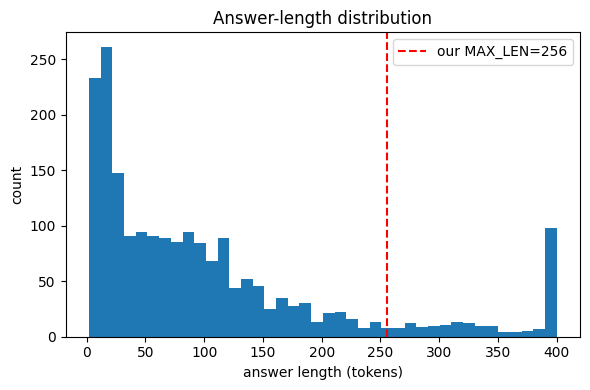

In [20]:
# Quick dataset profiling: how long are the answers? (drives our MAX_LEN choice)
sample = raw.shuffle(seed=42).select(range(2000))
ans_tok_lens = [len(tokenizer(e["output"])["input_ids"]) for e in sample if (e.get("output") or "").strip()]

print(f"Answer length (tokens): min={min(ans_tok_lens)}  median={int(np.median(ans_tok_lens))}  "
      f"mean={np.mean(ans_tok_lens):.0f}  p90={int(np.percentile(ans_tok_lens,90))}  max={max(ans_tok_lens)}")

plt.figure(figsize=(6,4))
plt.hist(np.clip(ans_tok_lens, 0, 400), bins=40)
plt.axvline(256, color="red", linestyle="--", label="our MAX_LEN=256")
plt.xlabel("answer length (tokens)"); plt.ylabel("count")
plt.title("Answer-length distribution"); plt.legend()
plt.tight_layout(); plt.show()
# Most answers fit under 256 tokens, so MAX_LEN=256 truncates few examples while keeping training fast.

### 3.3 — Prompt template design

Consistency is everything: training and evaluation must use the **exact same** template so the model
learns to start answering right after `### Response:`. We handle both the with-context and
no-context cases.

In [21]:
PROMPT_NO_INPUT = (
    "Below is a finance question. Write a helpful, accurate answer.\n\n"
    "### Question:\n{instruction}\n\n### Response:\n"
)
PROMPT_WITH_INPUT = (
    "Below is a finance question with extra context. Write a helpful, accurate answer.\n\n"
    "### Question:\n{instruction}\n\n### Context:\n{input}\n\n### Response:\n"
)

def build_prompt(example):
    # Return ONLY the prompt (up to "### Response:") -- used at generation time.
    instr = (example.get("instruction") or "").strip()
    inp   = (example.get("input") or "").strip()
    if inp:
        return PROMPT_WITH_INPUT.format(instruction=instr, input=inp)
    return PROMPT_NO_INPUT.format(instruction=instr)

def format_example(example):
    # Prompt + reference answer + EOS -- the full text the model trains on.
    answer = (example.get("output") or "").strip()
    return {"text": build_prompt(example) + answer + tokenizer.eos_token}

# Keep only examples that have both a question and an answer.
raw = raw.filter(lambda e: (e.get("instruction") or "").strip() and (e.get("output") or "").strip())
raw = raw.shuffle(seed=42)

# Time-boxed subsets so training + eval finish inside the class.
train_raw = raw.select(range(200))            # fine-tune on 1000 Q&A pairs
eval_raw  = raw.select(range(200, 250))      # 200 held-out for evaluation (never trained on)
train_ds  = train_raw.map(format_example, remove_columns=train_raw.column_names)

print("Train:", len(train_ds), "| Eval:", len(eval_raw))
print("\n--- one fully formatted training example ---\n")
print(train_ds[0]["text"][:700])

Filter:   0%|          | 0/68912 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Train: 200 | Eval: 50

--- one fully formatted training example ---

Below is a finance question. Write a helpful, accurate answer.

### Question:
Expiring 401(k) Stock Option and Liquidation Implications

### Response:
I have had this happen a couple of times because of splits or sales of portions of the company.  The general timeline was to announce how the split was to be handled; then the split; then a freeze in purchasing stock in the other company; then a freeze in sales; followed by a short blackout period; then the final transfers to funds/options/cash based on a mapping announced at the start of the process. You need to answer two questions: To determine if the final transactions will make the market move you have to understand how many shares are in


### 3.4 — Tokenize and inspect what the model sees

We tokenize with truncation but **without** padding — a data collator pads each batch dynamically to
its own longest example (faster than padding everything to `MAX_LEN`). For causal LM, the collator
also builds `labels` from `input_ids` and masks padding to `-100` (ignored by the loss).

In [22]:
from transformers import DataCollatorForLanguageModeling

MAX_LEN = 256

def tokenize_fn(batch):
    # No padding here -> the collator pads per-batch. Truncate to MAX_LEN.
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)

# mlm=False -> causal (next-token) LM: labels = input_ids, pad positions -> -100.
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Inspect one tokenized example + how the collator builds a training batch.
ex0 = train_tok[0]
print("input_ids length :", len(ex0["input_ids"]))
batch = data_collator([train_tok[0], train_tok[1]])   # collate two examples
print("Batched shapes   :", {k: tuple(v.shape) for k, v in batch.items()})
print("labels == input_ids on real tokens? ",
      bool((batch['labels'][0][:10] == batch['input_ids'][0][:10]).all().item()))
print("(-100 in labels marks padding the loss ignores.)")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

input_ids length : 256
Batched shapes   : {'input_ids': (2, 256), 'attention_mask': (2, 256), 'labels': (2, 256)}
labels == input_ids on real tokens?  True
(-100 in labels marks padding the loss ignores.)


### 3.5 — Attach the QLoRA adapters

Three steps: (1) `prepare_model_for_kbit_training` makes the frozen 4-bit model safe to backprop
through (fp32 layernorms, input grads, gradient checkpointing); (2) define the LoRA config;
(3) wrap the model so only adapters train.

In [23]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

# (1) Prepare the quantized model for k-bit training.
model_qlora = prepare_model_for_kbit_training(model_4bit)

# (2) Describe the adapters.
lora_config = LoraConfig(
    r=16,                # rank: capacity vs memory (see 3.1 table)
    lora_alpha=32,       # scaling for the LoRA update (~2x r is a common rule of thumb)
    lora_dropout=0.05,   # light regularization on the adapters
    bias="none",         # don't train biases -> fewer trainable params
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",   # attention projections
                    "gate_proj", "up_proj", "down_proj"],     # MLP projections
)

# (3) Attach. Base stays frozen in 4-bit; only adapters are trainable.
model_qlora = get_peft_model(model_qlora, lora_config)

trainable = sum(p.numel() for p in model_qlora.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_qlora.parameters())
print(f"Trainable params : {trainable:,}")
print(f"Total params     : {total:,}")
print(f"Trainable %      : {100*trainable/total:.4f}%   (matches our 3.1 estimate)")

Trainable params : 39,976,960
Total params     : 3,540,389,888
Trainable %      : 1.1292%   (matches our 3.1 estimate)


In [24]:
# Confirm WHICH layers actually received adapters (LoRA injects lora_A / lora_B pairs).
lora_layers = [n for n, _ in model_qlora.named_modules() if n.endswith("lora_A.default")]
print(f"Adapters injected into {len(lora_layers)} layers. First 7:")
for n in lora_layers[:7]:
    print("  ", n.replace(".lora_A.default", ""))

Adapters injected into 224 layers. First 7:
   base_model.model.model.layers.0.self_attn.q_proj
   base_model.model.model.layers.0.self_attn.k_proj
   base_model.model.model.layers.0.self_attn.v_proj
   base_model.model.model.layers.0.self_attn.o_proj
   base_model.model.model.layers.0.mlp.gate_proj
   base_model.model.model.layers.0.mlp.up_proj
   base_model.model.model.layers.0.mlp.down_proj


## Part 4 — Module 3: Evaluate before vs after

We measure the model **twice** with identical tools: now (before training) and again after.

- **Perplexity** on held-out data — `exp(mean next-token loss)`. Lower = the model finds the domain
  text more predictable. Generation-free, fast, clean.
- **ROUGE-1/2/L** between generated answers and references — higher = more overlap with the truth.
- **Qualitative** side-by-side reading — numbers miss things the eye catches.

**Why "before" is a fair baseline:** LoRA initializes its `B` matrix to zero, so a freshly-adapted
model behaves *identically to the frozen base*. Measuring now = measuring the untrained 4-bit model.

Order: define helpers → **before** snapshot → train → **after** snapshot → compare.

In [ ]:
from rouge_score import rouge_scorer

# --- perplexity over a held-out subset ---
def perplexity(model, dataset, n=100):
    model.eval()
    losses = []
    for ex in dataset.select(range(min(n, len(dataset)))):
        text = build_prompt(ex) + (ex.get("output") or "").strip() + tokenizer.eos_token
        enc  = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(model.device)
        with torch.no_grad():
            loss = model(**enc, labels=enc["input_ids"]).loss   # standard next-token loss
        losses.append(loss.item())
    return float(np.exp(np.mean(losses)))

# --- ROUGE-1/2/L between generated and reference answers ---
_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def rouge_scores(model, dataset, n=25, max_new_tokens=120):
    model.eval()
    agg = {"rouge1": [], "rouge2": [], "rougeL": []}
    for ex in dataset.select(range(min(n, len(dataset)))):
        _, _, gen = generate(model, build_prompt(ex), max_new_tokens=max_new_tokens)
        ref = (ex.get("output") or "").strip()
        s = _scorer.score(ref, gen)
        for k in agg:
            agg[k].append(s[k].fmeasure)
    return {k: float(np.mean(v)) for k, v in agg.items()}

# Fixed held-out questions we'll read before AND after (same prompts each time).
qual_examples = [eval_raw[i] for i in range(2)]
print("Evaluation helpers ready.")

Evaluation helpers ready.


In [ ]:
# ============ BEFORE-TRAINING SNAPSHOT (adapters=0 -> base behavior) ============
print("Measuring BEFORE fine-tuning...\n")
before_ppl   = perplexity(model_qlora, eval_raw, n=100)
before_rouge = rouge_scores(model_qlora, eval_raw, n=25)
before_answers = [generate(model_qlora, build_prompt(ex), max_new_tokens=120)[2] for ex in qual_examples]

print(f"BEFORE perplexity : {before_ppl:.2f}")
print(f"BEFORE ROUGE       : "
      f"R1={before_rouge['rouge1']:.4f}  R2={before_rouge['rouge2']:.4f}  RL={before_rouge['rougeL']:.4f}")
gpu_report("before training")

Measuring BEFORE fine-tuning...

BEFORE perplexity : 3.97
BEFORE ROUGE       : R1=0.3707  R2=0.1847  RL=0.3071
[before training       ] used 10.92 GB / 15.6 GB  |  allocated  9.50 GB  |  reserved 10.64 GB


### 4.1 — Training hyperparameters (why each value)

- `per_device_train_batch_size=1` + `gradient_accumulation_steps=16` → effective batch 16, but only
  one example in memory at a time (fits 7B on a T4).
- `learning_rate=2e-4` → typical for LoRA (higher than full fine-tuning; we train few params).
- `optim="paged_adamw_8bit"` → 8-bit optimizer, a big memory saver (needs bitsandbytes).
- `gradient_checkpointing=True` → recompute activations in the backward pass instead of storing them
  (trades compute for memory).
- `fp16/bf16` → matched to the GPU (Part 0).

`use_cache` and gradient checkpointing conflict, so we disable the cache during training and re-enable
it for generation afterward.

In [ ]:
from transformers import TrainingArguments, Trainer

model_qlora.config.use_cache = False   # required with gradient checkpointing

training_args = TrainingArguments(
    output_dir="./qlora-llama2-finance",
    num_train_epochs=1,                 # one pass gives a clearly visible improvement
    per_device_train_batch_size=1,      # small per-step batch to fit 7B on 15 GB...
    gradient_accumulation_steps=16,     # ...accumulate to an effective batch of 16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=5,                    # log loss often so we can plot a smooth curve
    save_strategy="no",                 # we save adapters manually at the end
    report_to="none",
    optim="paged_adamw_8bit",           # 8-bit optimizer -> memory saver
    gradient_checkpointing=True,        # recompute activations -> memory saver
    fp16=not USE_BF16, bf16=USE_BF16,   # precision matched to the GPU
)

trainer = Trainer(
    model=model_qlora,
    args=training_args,
    train_dataset=train_tok,
    data_collator=data_collator,
)

train_result = trainer.train()
print("\nDone. Final train loss:", round(train_result.training_loss, 4))

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
5,1.973441
10,1.530410



Done. Final train loss: 1.7023


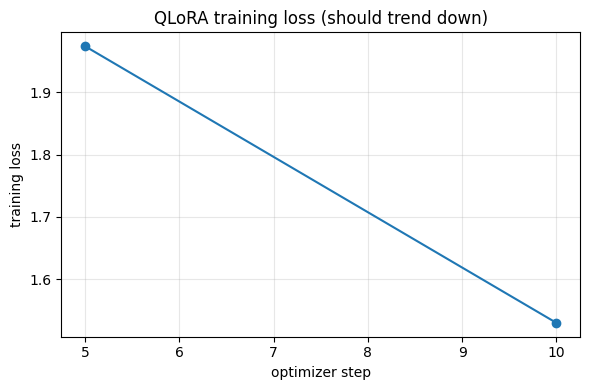

[after training        ] used 10.92 GB / 15.6 GB  |  allocated  9.50 GB  |  reserved 10.64 GB


In [ ]:
# Plot the training loss curve from the Trainer's logged history.
hist  = trainer.state.log_history
steps = [h["step"] for h in hist if "loss" in h]
loss  = [h["loss"] for h in hist if "loss" in h]

plt.figure(figsize=(6,4))
plt.plot(steps, loss, marker="o")
plt.xlabel("optimizer step"); plt.ylabel("training loss")
plt.title("QLoRA training loss (should trend down)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
gpu_report("after training")

In [ ]:
# ============ AFTER-TRAINING SNAPSHOT ============
model_qlora.config.use_cache = True   # re-enable cache for fast generation
print("Measuring AFTER fine-tuning...\n")
after_ppl   = perplexity(model_qlora, eval_raw, n=100)
after_rouge = rouge_scores(model_qlora, eval_raw, n=25)
after_answers = [generate(model_qlora, build_prompt(ex), max_new_tokens=120)[2] for ex in qual_examples]

print(f"AFTER perplexity : {after_ppl:.2f}")
print(f"AFTER ROUGE       : "
      f"R1={after_rouge['rouge1']:.4f}  R2={after_rouge['rouge2']:.4f}  RL={after_rouge['rougeL']:.4f}")

Measuring AFTER fine-tuning...

AFTER perplexity : 3.97
AFTER ROUGE       : R1=0.4385  R2=0.2183  RL=0.3397


In [ ]:
# ---- Numeric comparison ----
def pct(b, a): return (a - b) / b * 100 if b else float('nan')

print(f"{'Metric':<12}{'Before':>10}{'After':>10}{'Change':>12}")
print("-" * 44)
print(f"{'Perplexity':<12}{before_ppl:>10.2f}{after_ppl:>10.2f}{pct(before_ppl, after_ppl):>11.1f}%  (down = better)")
for k, label in [("rouge1","ROUGE-1"), ("rouge2","ROUGE-2"), ("rougeL","ROUGE-L")]:
    print(f"{label:<12}{before_rouge[k]:>10.4f}{after_rouge[k]:>10.4f}{pct(before_rouge[k], after_rouge[k]):>11.1f}%  (up = better)")

Metric          Before     After      Change
--------------------------------------------
Perplexity        3.97      3.97        0.0%  (down = better)
ROUGE-1         0.3707    0.4385       18.3%  (up = better)
ROUGE-2         0.1847    0.2183       18.2%  (up = better)
ROUGE-L         0.3071    0.3397       10.6%  (up = better)


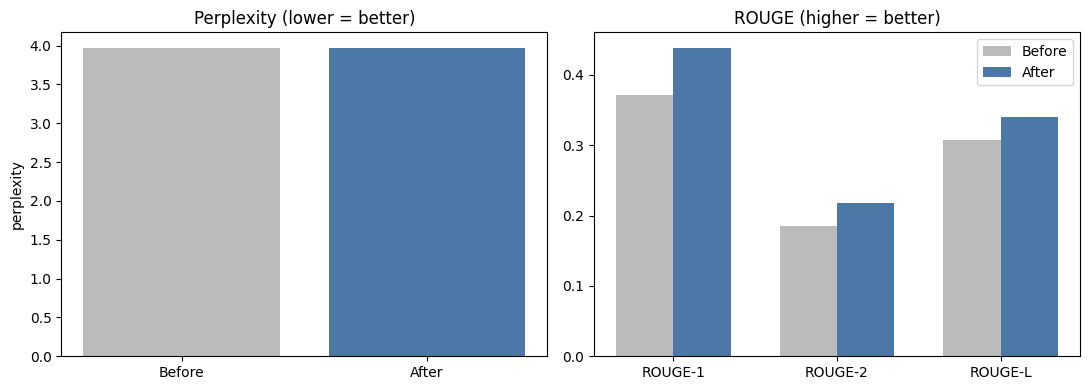

In [ ]:
# ---- Visual comparison: perplexity (left) and ROUGE (right) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(["Before", "After"], [before_ppl, after_ppl], color=["#bbb", "#4c78a8"])
ax1.set_title("Perplexity (lower = better)"); ax1.set_ylabel("perplexity")

labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
b = [before_rouge["rouge1"], before_rouge["rouge2"], before_rouge["rougeL"]]
a = [after_rouge["rouge1"],  after_rouge["rouge2"],  after_rouge["rougeL"]]
x = np.arange(len(labels)); w = 0.35
ax2.bar(x - w/2, b, w, label="Before", color="#bbb")
ax2.bar(x + w/2, a, w, label="After",  color="#4c78a8")
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_title("ROUGE (higher = better)"); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ---- Qualitative: read the actual answers on the same held-out questions ----
for i, ex in enumerate(qual_examples):
    print("=" * 92)
    print("Q         :", (ex.get("instruction") or "").strip()[:280])
    print("-" * 92)
    print("BEFORE    :", before_answers[i][:360])
    print("-" * 92)
    print("AFTER     :", after_answers[i][:360])
    print("-" * 92)
    print("REFERENCE :", (ex.get("output") or "").strip()[:360])
    print()

Q         : Credit card statement dates follow pattern?
--------------------------------------------------------------------------------------------
BEFORE    : Credit card statement dates follow a predictable pattern. The statement date is typically the first day of the billing cycle, which is the period of time during which the cardholder's balance is calculated. The billing cycle is typically 28 to 30 days, but it can vary depending on the issuer. The statement date is typically the first day of the billing cycle
--------------------------------------------------------------------------------------------
AFTER     : Credit card statement dates follow a predictable pattern. They typically follow the same day of the month as the previous statement, with a few exceptions. For example, if the previous statement was on the 15th, the next statement will typically be on the 15th or 16th. However, there are some exceptions, such as when the credit card issuer changes the statem
------------

**Reading the results.** Expect perplexity to drop and ROUGE to rise, with the "after" answers
staying on-format and on-domain where the base model rambled. Remember automatic metrics are proxies:
ROUGE rewards n-gram overlap, so a *correct* answer worded differently from the reference can still
score low. Always pair metrics with qualitative reading — which is exactly why we kept both.

## Part 5 — Save, reload, and deploy

QLoRA's shipping story: distribute only the **adapters** (a few MB). The frozen base is downloaded
once and shared across many fine-tunes.

In [ ]:
# Save ONLY the LoRA adapters (tiny) + tokenizer. The 7B base is NOT duplicated.
adapter_dir = "./llama2-finance-qlora-adapter"
model_qlora.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)

print("Saved adapter size:")
!du -sh {adapter_dir}
print("\nFiles:")
!ls -lh {adapter_dir}

Saved adapter size:
157M	./llama2-finance-qlora-adapter

Files:
total 157M
-rw-r--r-- 1 root root 1.1K Jul 23 18:52 adapter_config.json
-rw------- 1 root root 153M Jul 23 18:52 adapter_model.safetensors
-rw-r--r-- 1 root root 5.1K Jul 23 18:52 README.md
-rw-r--r-- 1 root root  399 Jul 23 18:52 tokenizer_config.json
-rw-r--r-- 1 root root 3.5M Jul 23 18:52 tokenizer.json


In [ ]:
# How to reload later for inference (pattern; commented so we don't re-load 13 GB now).
# from peft import PeftModel
# base = AutoModelForCausalLM.from_pretrained(
#     model_name, quantization_config=bnb_config, device_map="auto")
# tok   = AutoTokenizer.from_pretrained(adapter_dir)
# model = PeftModel.from_pretrained(base, adapter_dir)     # attach the saved adapters
# # For deployment you can fold adapters into the base:
# # model = model.merge_and_unload()   # NOTE: dequantizes to fp16 first; skip to stay 4-bit
#
# Deployment recipe: ship {adapter_dir} (a few MB) + point users at the base model on the Hub.
print("Reload = base (4-bit) + adapters. A few MB per fine-tune, one shared base. That's the win.")

Reload = base (4-bit) + adapters. A few MB per fine-tune, one shared base. That's the win.


## Part 6 — The method landscape & wrap-up

**What you did today, end to end:**
1. Built quantization intuition with runnable demos (bit precision, symmetric/asymmetric, per-channel,
   the bit-width cliff, NF4's distribution-aware levels, and the training-vs-inference memory math).
2. Loaded **LLaMA-2-7B in 4-bit NF4** on one GPU (~8x smaller than FP16) and generated text.
3. Fine-tuned it with **QLoRA**, training **<1%** of the parameters.
4. Evaluated **before vs after** with perplexity, ROUGE, a loss curve, comparison charts, and reading.
5. Saved deployable adapters.

**Choosing a quantization method (beyond bitsandbytes):**

| Method | Bits | Best for | Notes |
|---|---|---|---|
| **bitsandbytes NF4** | 4 | **QLoRA fine-tuning** (today) | on-the-fly, no calibration, HF-native |
| **GPTQ** | 3–4 | fast *inference* serving | offline, needs a calibration set, per-layer solve |
| **AWQ** | 4 | inference, quality-sensitive | protects activation-important weights |
| **GGUF (llama.cpp)** | 2–8 | **CPU / laptop / edge** | great for local desktop apps, many bit options |

Rule of thumb: **QLoRA/bitsandbytes to fine-tune**, **GPTQ/AWQ to serve on GPU**, **GGUF to run on CPU/edge**.

**Knobs that matter most (tune these first):**
- LoRA `r` / `lora_alpha` — adapter capacity vs memory.
- `target_modules` — attention-only vs attention+MLP.
- `MAX_LEN`, batch size, `gradient_accumulation_steps` — the memory/speed/quality triangle.
- `bnb_4bit_quant_type` — `nf4` (default) vs `fp4`.
- **Prompt-format consistency** between training and evaluation.

**When quantization hurts:** tasks needing maximum precision or subtle multi-step reasoning, or
aggressive *activation* quantization done carelessly. If quality drops: verify compute dtype, raise
LoRA `r`, or step up to 8-bit.

**Run this on your own machine:** identical code. Any CUDA GPU with ~12 GB+ (RTX 3060/4060, T4, …)
runs it — Colab's T4 was just a stand-in for a local card.

**Further reading:** QLoRA (Dettmers et al., 2023) · LoRA (Hu et al., 2021) · NF4 & double-quant
(bitsandbytes) · GPTQ (Frantar et al., 2022) · AWQ (Lin et al., 2023) · PEFT & Transformers docs.
